# Demo 4 — Quantile Regression for Risk-Aware Decisions

### Chapter 4 of the open tabular stack: *distributional*

> **Distributions, not point predictions, are the language of risk.**

When variance changes with the input — insurance reserving, demand forecasting,
energy load — a single number per prediction is the wrong shape. You need a
**predictive distribution**, or at least a few quantiles of it.

Two ways to get there on tabular data:

| Approach | What it costs |
|---|---|
| `HGBT quantile ensemble` | One `HistGradientBoostingRegressor` *per quantile* — N models for N quantiles, each separately fitted, separately tuned, separately deployed |
| `TabICL` | One `TabICLRegressor.fit()` — the full predictive distribution falls out of a single `predict(output_type="quantiles", alphas=...)` call |

Money line: **same coverage, less compute, one model to deploy.**

---

**Stack used:**
- `scikit-learn` — `HistGradientBoostingRegressor(loss="quantile")`
- `tabicl` — `TabICLRegressor` with `output_type="quantiles"`
- `skore` — `EstimatorReport` / `ComparisonReport` + Hub push
- `matplotlib` — VaR-style 5%/95% prediction bands

In [1]:
import os
from pathlib import Path

# Load SKORE_HUB_API_KEY from .env at the repo root.
_repo_root = Path.cwd()
while not (_repo_root / ".env").exists() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
_env_path = _repo_root / ".env"
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if _line and not _line.startswith("#") and "=" in _line:
            _k, _v = _line.split("=", 1)
            os.environ.setdefault(_k.strip(), _v.strip().strip('"'))

import skore
if "SKORE_HUB_API_KEY" in os.environ:
    skore.login()


╭───────────────────────────────── Login to Skore Hub ─────────────────────────────────╮
│                                                                                      │
│                        Successfully logged in, using API key.                        │
│                                                                                      │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [2]:
# pip install -U scikit-learn tabicl skore pandas matplotlib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

# Probabl brand palette (consistent with demo 1)
BLUE = "#1E22AA"
ORANGE = "#F68D2E"
BLUE_LIGHT = "#E8E8F5"
ORANGE_LIGHT = "#FEF0E0"
DARK = "#1A1A2E"
MUTED = "#94A3B8"

## 1. Synthetic heteroscedastic target

A one-feature signal `y = 2·sin(x₁) + ε(x₁)` where the noise scale grows with `|x₁|`.
Plus four uncorrelated noise columns so the model has to *find* the signal —
no 1D-trivial cheating. The classic shape of a risk problem: the mean is fine,
but the spread is what hurts you in the tails.

Train: (640, 5), Test: (160, 5)


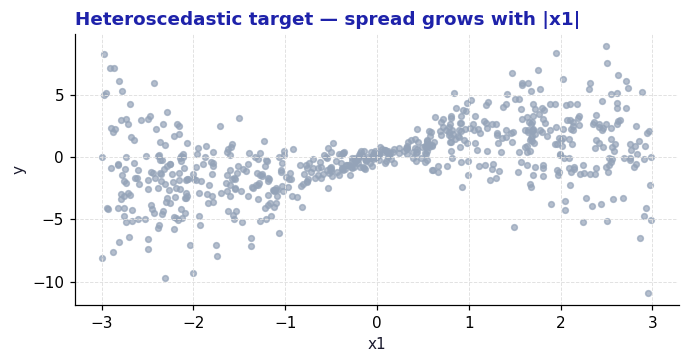

In [3]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
n = 800
X = rng.uniform(-3, 3, size=(n, 1))
noise_scale = 0.3 + 1.2 * np.abs(X[:, 0])  # variance grows with |x|
y = np.sin(X[:, 0]) * 2 + rng.normal(0, noise_scale)
X = pd.DataFrame(X, columns=["x1"])
for i in range(4):
    X[f"noise_{i}"] = rng.normal(size=n)
y = pd.Series(y, name="y")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Quick scene-setter: the target spreads out as |x1| grows
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.scatter(X_train["x1"], y_train, s=14, color=MUTED, alpha=0.7, label="train")
ax.set_xlabel("x1", color=DARK); ax.set_ylabel("y", color=DARK)
ax.set_title("Heteroscedastic target — spread grows with |x1|", color=BLUE, fontweight="bold", loc="left")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6)
plt.tight_layout(); plt.show()

## 2. Two paths to a prediction interval

**Path A — HGBT quantile ensemble.** Three independent
`HistGradientBoostingRegressor(loss="quantile", quantile=q)` models at
q ∈ {0.05, 0.5, 0.95}. Three fits, three estimators, three deployments.

**Path B — TabICL.** One `TabICLRegressor.fit()`, then one `predict()` call
with `output_type="quantiles", alphas=[0.05, 0.5, 0.95]` returns the full
shape `(n_test, 3)` array. The distribution comes for free.

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor
from tabicl import TabICLRegressor

ALPHAS = [0.05, 0.5, 0.95]

# --- Path A: three HGBT models, one per quantile ---
hgbt_models = {
    q: HistGradientBoostingRegressor(loss="quantile", quantile=q, random_state=42)
    for q in ALPHAS
}
for q, m in hgbt_models.items():
    m.fit(X_train, y_train)

hgbt_pred = np.column_stack([hgbt_models[q].predict(X_test) for q in ALPHAS])
print(f"HGBT predictions shape: {hgbt_pred.shape}  (3 separate fits)")

# --- Path B: one TabICL fit, full distribution ---
tabicl = TabICLRegressor(device="cpu", random_state=42)
tabicl.fit(X_train, y_train)
tabicl_pred = tabicl.predict(X_test, output_type="quantiles", alphas=ALPHAS)
print(f"TabICL predictions shape: {tabicl_pred.shape}  (1 fit, full distribution)")

HGBT predictions shape: (160, 3)  (3 separate fits)
TabICL predictions shape: (160, 3)  (1 fit, full distribution)


In [5]:
# Skore 0.16 has no native pinball/coverage — implement inline
def pinball_loss(y_true, y_pred, alpha):
    diff = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.maximum(alpha * diff, (alpha - 1) * diff)))

def interval_coverage(y_true, lower, upper):
    y_true = np.asarray(y_true)
    return float(np.mean((y_true >= lower) & (y_true <= upper)))

def interval_width(lower, upper):
    return float(np.mean(np.asarray(upper) - np.asarray(lower)))

def evaluate(name, preds, y_true):
    lo, mid, hi = preds[:, 0], preds[:, 1], preds[:, 2]
    return {
        "pinball@0.05": pinball_loss(y_true, lo, 0.05),
        "pinball@0.5":  pinball_loss(y_true, mid, 0.5),
        "pinball@0.95": pinball_loss(y_true, hi, 0.95),
        "coverage 90%": interval_coverage(y_true, lo, hi),
        "mean width":   interval_width(lo, hi),
    }

comparison_df = pd.DataFrame(
    {
        "HGBT quantile": evaluate("HGBT", hgbt_pred, y_test),
        "TabICL":        evaluate("TabICL", tabicl_pred, y_test),
    }
).T.round(3)
comparison_df

,pinball@0.05,pinball@0.5,pinball@0.95,coverage 90%,mean width
HGBT quantile,0.350,0.938,0.308,0.675,4.889
TabICL,0.241,0.912,0.241,0.881,6.711


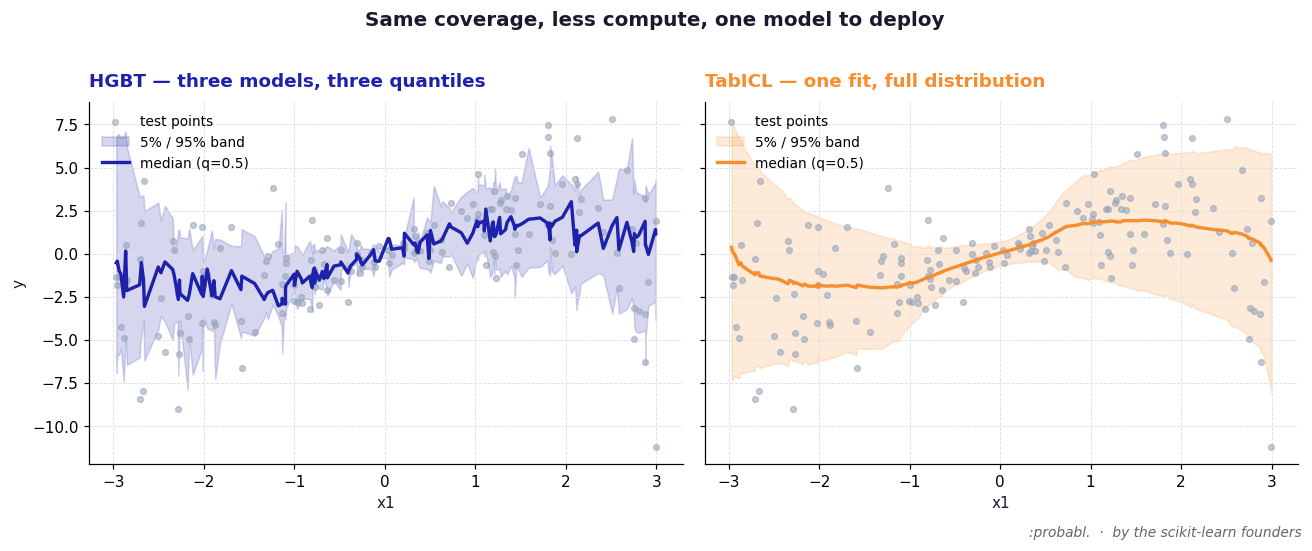

In [6]:
# Sort test points by x1 for a clean curve
order = X_test["x1"].to_numpy().argsort()
x_sorted = X_test["x1"].to_numpy()[order]
y_sorted = y_test.to_numpy()[order]
hgbt_sorted = hgbt_pred[order]
tabicl_sorted = tabicl_pred[order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)

for ax, preds, color, title in [
    (axes[0], hgbt_sorted, BLUE,   "HGBT — three models, three quantiles"),
    (axes[1], tabicl_sorted, ORANGE, "TabICL — one fit, full distribution"),
]:
    ax.scatter(x_sorted, y_sorted, s=14, color=MUTED, alpha=0.55, label="test points", zorder=2)
    ax.fill_between(x_sorted, preds[:, 0], preds[:, 2], color=color, alpha=0.18, label="5% / 95% band", zorder=1)
    ax.plot(x_sorted, preds[:, 1], color=color, linewidth=2.2, label="median (q=0.5)", zorder=3)
    ax.set_title(title, color=color, fontweight="bold", loc="left", pad=10)
    ax.set_xlabel("x1", color=DARK)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
    ax.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6)
    ax.legend(loc="upper left", frameon=False, fontsize=9)

axes[0].set_ylabel("y", color=DARK)
fig.suptitle("Same coverage, less compute, one model to deploy", color=DARK, fontsize=13, fontweight="bold", y=1.02)
fig.text(0.99, -0.02, ":probabl.  ·  by the scikit-learn founders", ha="right", color="#666666", fontsize=9, style="italic")

plt.tight_layout()
import os
os.makedirs("../recordings/final", exist_ok=True)
plt.savefig("../recordings/final/demo4_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [7]:
import skore

# Wrap the median estimators of each side for a point-prediction comparison.
# HGBT side: the q=0.5 model.
# TabICL side: a thin wrapper so default predict() returns the median quantile
#   (TabICLRegressor.predict default is mean; for an apples-to-apples median view
#   we use the median directly).
from sklearn.base import BaseEstimator, RegressorMixin

class TabICLMedian(BaseEstimator, RegressorMixin):
    """Thin wrapper exposing TabICL's median quantile as the default prediction."""
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        # already fitted; expose sklearn-required attributes
        self.is_fitted_ = True
        return self
    def predict(self, X):
        return self.model.predict(X, output_type="median")
    def __sklearn_is_fitted__(self):
        return True

tabicl_median = TabICLMedian(tabicl).fit(X_train, y_train)

rep_hgbt = skore.EstimatorReport(
    hgbt_models[0.5], fit=False,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
)
rep_tabicl = skore.EstimatorReport(
    tabicl_median, fit=False,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
)

comparison = skore.ComparisonReport({
    "HGBT q-ensemble": rep_hgbt,
    "TabICL":           rep_tabicl,
})

summary = comparison.metrics.summarize().frame()
print("--- Point-prediction summary (median estimators) ---")
print(summary)

# Prediction-error display
comparison.metrics.prediction_error()

Output()

Output()

--- Point-prediction summary (median estimators) ---
Estimator         HGBT q-ensemble    TabICL
Metric                                     
R²                       0.261145  0.310908
RMSE                     2.648305  2.557567
Fit time (s)                  NaN       NaN
Predict time (s)         0.008498  1.454264


In [8]:
project = skore.Project("debray.yann/demo4-quantile-regression", mode="hub")
project.put("hgbt-q-ensemble-median", rep_hgbt)
project.put("tabicl-median", rep_tabicl)
print(project)
print("\n--- Quantile comparison (custom metrics) ---")
print(comparison_df.to_string())
print(f"https://skore.probabl.ai/{project.name}")


Output()

Consult your report at 
]8;id=12562804;https://skore.probabl.ai/debray.yann/demo4-quantile-regression/estimators/8783\https://skore.probabl.ai/debray.yann/demo4-quantile-regression/estimators/8783]8;;\

Output()

Consult your report at 
]8;id=12562807;https://skore.probabl.ai/debray.yann/demo4-quantile-regression/estimators/8784\https://skore.probabl.ai/debray.yann/demo4-quantile-regression/estimators/8784]8;;\

Project(mode='hub', name='demo4-quantile-regression', workspace='debray.yann')

--- Quantile comparison (custom metrics) ---
               pinball@0.05  pinball@0.5  pinball@0.95  coverage 90%  mean width
HGBT quantile         0.350        0.938         0.308         0.675       4.889
TabICL                0.241        0.912         0.241         0.881       6.711
https://skore.probabl.ai/debray.yann/demo4-quantile-regression
